In [7]:
from google.colab import files
uploaded=files.upload()

Saving insurance.csv to insurance.csv


In [8]:
import pandas as pd
import numpy as np

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [11]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [12]:
df = pd.read_csv("insurance.csv")

In [13]:
print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [14]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
print("Shape:", df.shape)

Shape: (1337, 7)


In [17]:
print("\nAverage Age:", df['age'].mean())
print("Average BMI:", df['bmi'].mean())
print("Average Children:", df['children'].mean())
print("Average Charges:", df['charges'].mean())


Average Age: 39.222139117427076
Average BMI: 30.66345175766642
Average Children: 1.0957367240089753
Average Charges: 13279.121486655948


In [18]:
print(df.describe())

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


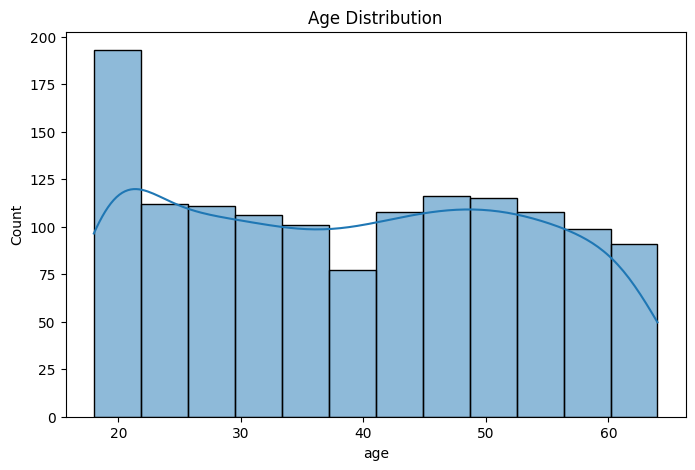

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


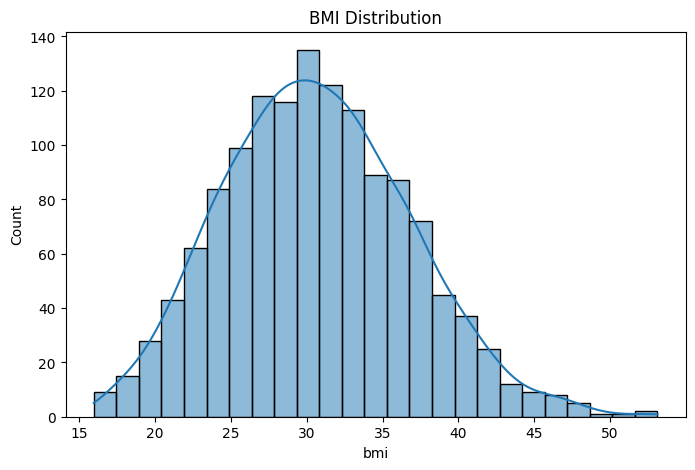

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

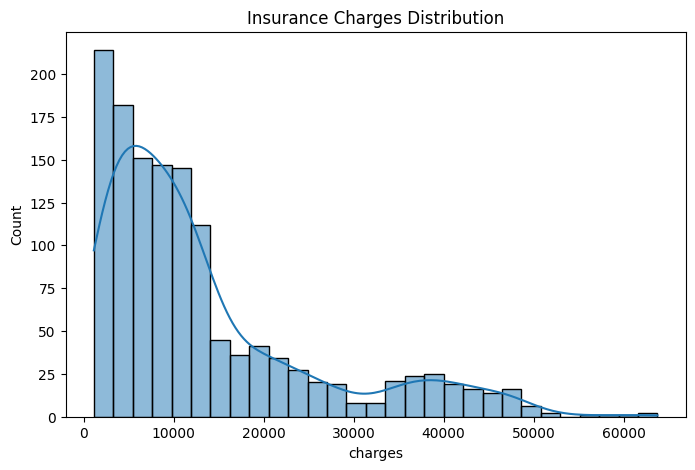

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

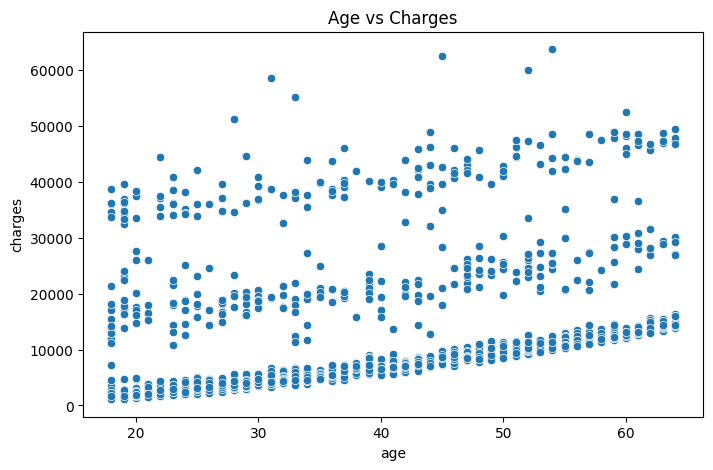

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

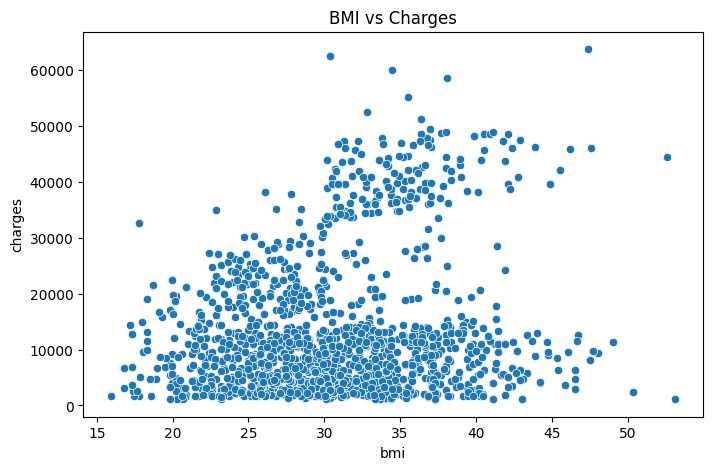

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()


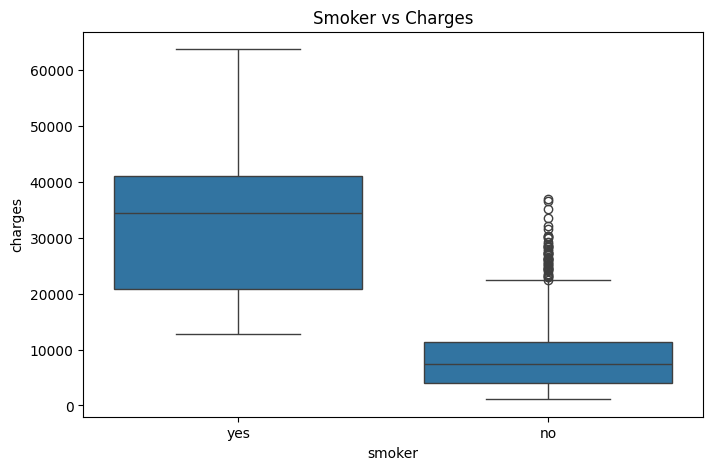

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Charges")
plt.show()


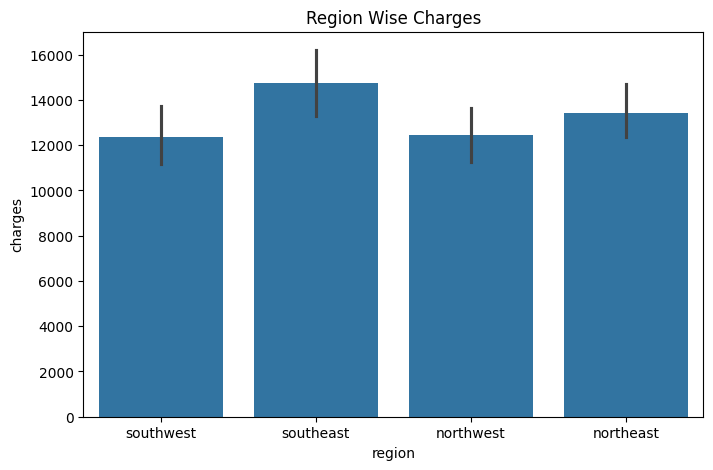

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='charges', data=df)
plt.title("Region Wise Charges")
plt.show()

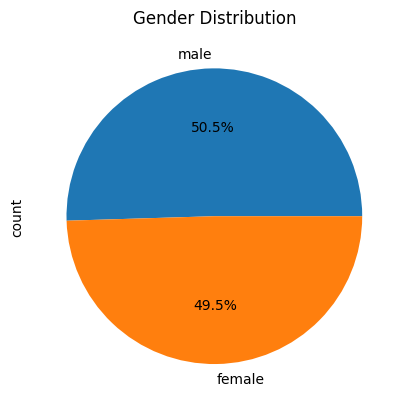

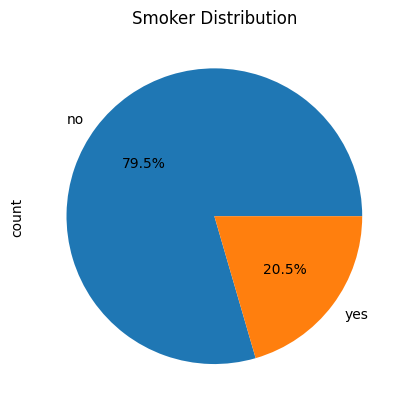

In [26]:
df['sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.show()

df['smoker'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Smoker Distribution")
plt.show()

In [27]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

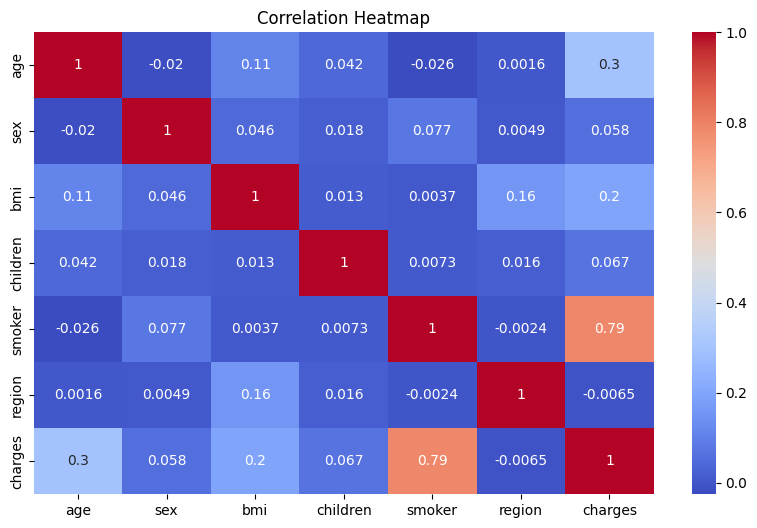

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
q1 = df['charges'].quantile(0.33)
q2 = df['charges'].quantile(0.66)

In [32]:
def classify_cost(x):

    if x <= q1:
        return "Low Cost"

    elif x <= q2:
        return "Medium Cost"

    else:
        return "High Cost"

In [33]:
df['risk_category'] = df['charges'].apply(classify_cost)


In [34]:
print(df['risk_category'].value_counts())


risk_category
High Cost      455
Low Cost       441
Medium Cost    441
Name: count, dtype: int64


In [35]:

X = df[['age']]
y = df['charges']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
lr = LinearRegression()

In [38]:
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
pred = lr.predict(X_test)

In [40]:
print("\nSIMPLE LINEAR REGRESSION")


SIMPLE LINEAR REGRESSION


In [41]:
print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2: 0.09513000782072023
MAE: 9657.78934976123
MSE: 166275348.23176482
RMSE: 12894.779883028823


In [42]:
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['charges']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
mlr = LinearRegression()


In [45]:
mlr.fit(X_train, y_train)


LinearRegression()

In [46]:
pred2 = mlr.predict(X_test)


In [47]:
print("\nMULTIPLE LINEAR REGRESSION")



MULTIPLE LINEAR REGRESSION


In [48]:
print("R2:", r2_score(y_test, pred2))
print("MAE:", mean_absolute_error(y_test, pred2))
print("MSE:", mean_squared_error(y_test, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred2)))


R2: 0.8045531086669288
MAE: 4198.592612356366
MSE: 35914551.48043363
RMSE: 5992.875059638206


In [49]:

median_charge = df['charges'].median()

In [50]:
df['insurance_category'] = np.where(
    df['charges'] > median_charge,
    1,
    0
)

In [51]:
X = df[['age', 'bmi', 'children', 'smoker']]
y = df['insurance_category']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
log_model = LogisticRegression(max_iter=1000)

In [54]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [55]:
pred3 = log_model.predict(X_test)

In [56]:
print("\nLOGISTIC REGRESSION")


LOGISTIC REGRESSION


In [57]:
print("Accuracy:",
      accuracy_score(y_test, pred3))

Accuracy: 0.9067164179104478


In [58]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred3))



Confusion Matrix
[[117  15]
 [ 10 126]]


In [59]:
print("\nClassification Report")
print(classification_report(y_test, pred3))


Classification Report
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       132
           1       0.89      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



In [60]:
import pandas as pd
import plotly.express as px

In [61]:
df = pd.read_csv("insurance.csv")

In [62]:
fig = px.histogram(
    df,
    x="charges",
    title="Insurance Charges Distribution"
)
fig.show()

In [63]:
fig = px.scatter(
    df,
    x="age",
    y="charges",
    color="smoker",
    title="Age vs Charges"
)
fig.show()

In [64]:
fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker",
    title="BMI vs Charges"
)
fig.show()

In [65]:
fig = px.box(
    df,
    x="smoker",
    y="charges",
    title="Smoker vs Charges"
)
fig.show()

In [66]:
fig = px.bar(
    df.groupby('region')['charges']
      .mean()
      .reset_index(),
    x='region',
    y='charges',
    title='Region Wise Charges'
)
fig.show()